# EDA — Challenge CFM : Prédiction des mouvements de stocks

Objectif : comprendre la structure des données avant de construire quoi que ce soit.
On répond à 6 questions clés qui vont guider toutes nos décisions de modélisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

In [2]:
X = pd.read_csv('../data/input_training.csv')
y = pd.read_csv('../data/output_training_hTMcdrS.csv')
X_test = pd.read_csv('../data/input_test.csv')

TARGET = 'end_of_day_return'

# Les colonnes de returns sont les colonnes au format HH:MM:SS
META_COLS = ['ID', 'eqt_code', 'date']
ret_cols = [c for c in X.columns if c not in META_COLS]

df = X.merge(y, on='ID')

print(f'X_train : {X.shape}  |  y_train : {y.shape}  |  X_test : {X_test.shape}')
print(f'Returns : {len(ret_cols)} colonnes ({ret_cols[0]} -> {ret_cols[-1]})')

X_train : (745327, 74)  |  y_train : (745327, 2)  |  X_test : (319769, 74)
Returns : 71 colonnes (09:30:00 -> 15:20:00)


---
## 1. Structure générale

Chaque ligne = une paire (stock, jour). On a 3 colonnes meta + 71 returns intraday (9h30 → 15h20).

In [3]:
print('Colonnes meta :', META_COLS)
print('Premiere colonne return :', ret_cols[0])
print('Derniere colonne return :', ret_cols[-1])
X.head(3)

Colonnes meta : ['ID', 'eqt_code', 'date']
Premiere colonne return : 09:30:00
Derniere colonne return : 15:20:00


,ID,eqt_code,date,09:30:00,09:35:00,09:40:00,09:45:00,09:50:00,09:55:00,10:00:00,...,14:35:00,14:40:00,14:45:00,14:50:00,14:55:00,15:00:00,15:05:00,15:10:00,15:15:00,15:20:00
0,0,975514820,2059277756,0.378421,0.062977,-1.699955,-0.253532,0.317230,-1.394081,-1.338014,...,-0.258339,-0.193950,0.129398,0.064666,0.323250,0.193705,0.387117,0.257687,0.064357,-0.193022
1,1,975514820,661006643,-0.588441,-0.393182,0.918810,0.392393,0.195901,-0.195754,0.000000,...,0.000000,-0.260940,0.000000,-0.130601,0.130666,0.130601,0.130536,0.521881,0.260419,0.910557
2,2,975514820,2252275018,-0.974472,1.789703,-0.105310,-0.456042,0.894337,-0.341168,-0.373679,...,-0.331103,-0.236124,-0.256959,-0.229774,0.063974,-0.570371,0.133774,-0.123741,-0.764930,0.230346


In [4]:
print(f"Jours uniques     : {X['date'].nunique()}")
print(f"Stocks uniques    : {X['eqt_code'].nunique()}")
print(f"Paires (s, d)     : {X.shape[0]:,}")
print(f"Paires theoriques : {X['date'].nunique() * X['eqt_code'].nunique():,}  (matrice incomplete)")

Jours uniques     : 1511
Stocks uniques    : 680
Paires (s, d)     : 745,327
Paires theoriques : 1,027,480  (matrice incomplete)


---
## 2. La target `end_of_day_return`

Return résiduel continu de 15h30 à 16h00. Une valeur de 0 signifie que le stock
a bougé exactement comme prévu par le marché (pas qu'il n'a pas bougé).

On prédit un **score continu** : si score > 0.5 → retour positif prédit.

In [6]:
print('dtype :', y[TARGET].dtype)
print(y[TARGET].describe().round(4))
print(f'\n% retours positifs (>0) : {(y[TARGET] > 0).mean():.2%}')
print(f'% retours negatifs (<0) : {(y[TARGET] < 0).mean():.2%}')
print(f'% exactement nuls (==0) : {(y[TARGET] == 0).mean():.2%}')

dtype : float64
count    745327.0000
mean          0.0002
std           0.9929
min         -44.5247
25%          -0.5359
50%          -0.0058
75%           0.5285
max          80.1886
Name: end_of_day_return, dtype: float64

% retours positifs (>0) : 49.71%
% retours negatifs (<0) : 50.29%
% exactement nuls (==0) : 0.00%


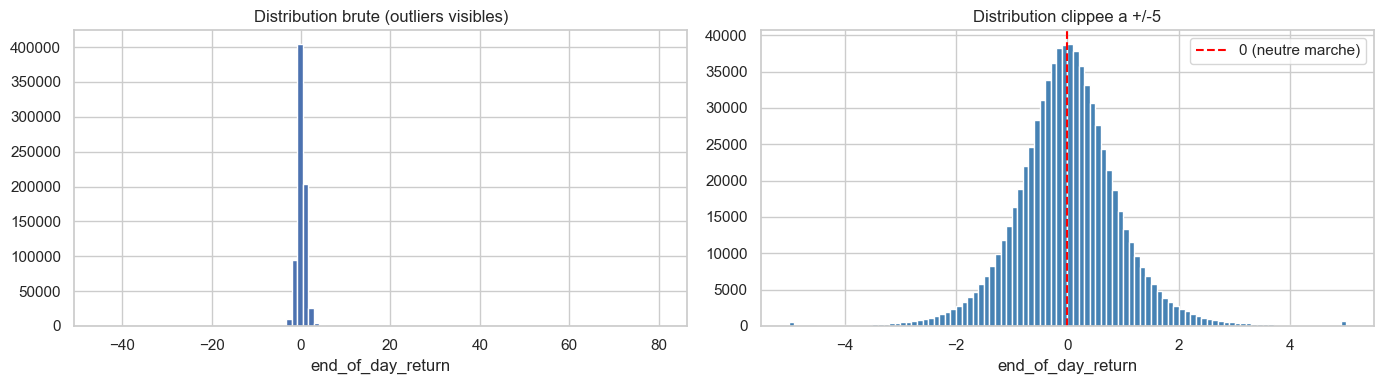

Classe 1 (return > 0) : 49.71%  — quasi equilibre


In [7]:
clip_target = 5

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

y[TARGET].hist(bins=100, ax=axes[0])
axes[0].set_title('Distribution brute (outliers visibles)')
axes[0].set_xlabel('end_of_day_return')

y[TARGET].clip(-clip_target, clip_target).hist(bins=100, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='0 (neutre marche)')
axes[1].set_title(f'Distribution clippee a +/-{clip_target}')
axes[1].set_xlabel('end_of_day_return')
axes[1].legend()
plt.tight_layout()
plt.show()

y_binary = (y[TARGET] > 0).astype(int)
print(f'Classe 1 (return > 0) : {y_binary.mean():.2%}  — quasi equilibre')

---
## 3. Valeurs manquantes (NaN)

In [8]:
nan_pct = X[ret_cols].isna().mean() * 100

print(f'NaN total : {X[ret_cols].isna().sum().sum():,}  ({X[ret_cols].isna().mean().mean():.1%} global)')
print(f'\nTop 5 colonnes avec le plus de NaN :')
print(nan_pct.sort_values(ascending=False).head(5).round(1))

NaN total : 347,646  (0.7% global)

Top 5 colonnes avec le plus de NaN :
12:50:00    1.1
12:55:00    1.1
12:40:00    1.1
12:45:00    1.1
12:25:00    1.0
dtype: float64


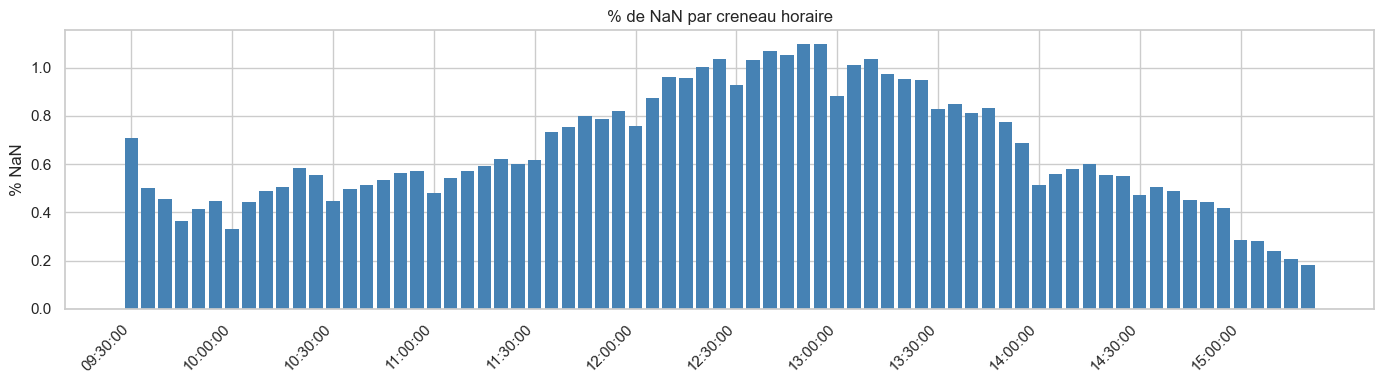

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(ret_cols)), nan_pct.values, color='steelblue', edgecolor='none')
ax.set_xticks(range(0, len(ret_cols), 6))
ax.set_xticklabels([ret_cols[i] for i in range(0, len(ret_cols), 6)], rotation=45, ha='right')
ax.set_title('% de NaN par creneau horaire')
ax.set_ylabel('% NaN')
plt.tight_layout()
plt.show()

---
## 4. Distribution des returns intraday — attention aux outliers

In [11]:
first_col = ret_cols[0]
print(f'Stats brutes sur {first_col} :')
print(X[first_col].describe().apply(lambda x: f'{x:.4g}'))
print(f'\nMax absolu tous returns : {X[ret_cols].abs().max().max():.4g}')
print(f'99.9e percentile        : {X[ret_cols].stack().quantile(0.999):.4g}')

Stats brutes sur 09:30:00 :
count     7.4e+05
mean      0.00318
std         3.821
min        -153.2
25%         -1.29
50%      0.005924
75%         1.303
max         368.3
Name: 09:30:00, dtype: str

Max absolu tous returns : 368.3
99.9e percentile        : 4.164


In [ ]:
# Volatilite au cours de la journee — pattern ouverture/fermeture ?
std_by_pos = X[ret_cols].clip(-500, 500).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(len(ret_cols)), std_by_pos.values, color='steelblue', linewidth=2)
ax.set_xticks(range(0, len(ret_cols), 6))
ax.set_xticklabels([ret_cols[i] for i in range(0, len(ret_cols), 6)], rotation=45, ha='right')
ax.set_title('Volatilite (std) par creneau horaire — clippe a +/-500')
ax.set_ylabel('Std du return')
plt.tight_layout()
plt.show()

---
## 5. Autocorrélation et prédictivité

Deux questions :
1. Les returns consécutifs sont-ils corrélés entre eux ? (justifie EWMA/rolling)
2. Quels créneaux horaires sont les plus corrélés avec la target ?

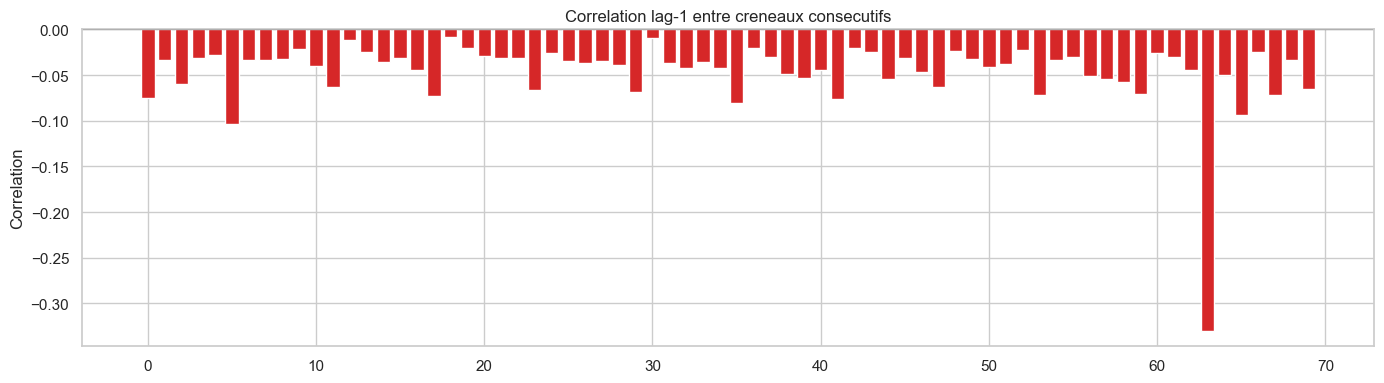

Correlation lag-1 moyenne : -0.0465


In [13]:
# Correlation lag-1 entre creneaux consecutifs
lag1_corr = [
    X[ret_cols[i]].clip(-500, 500).corr(X[ret_cols[i+1]].clip(-500, 500))
    for i in range(len(ret_cols) - 1)
]

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in lag1_corr]
ax.bar(range(len(lag1_corr)), lag1_corr, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlation lag-1 entre creneaux consecutifs')
ax.set_ylabel('Correlation')
plt.tight_layout()
plt.show()

print(f'Correlation lag-1 moyenne : {np.mean(lag1_corr):.4f}')

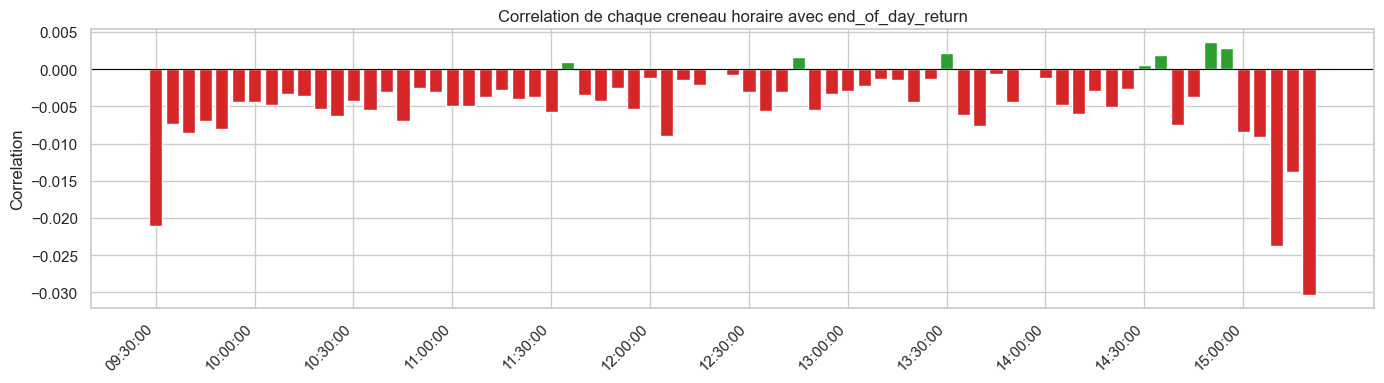

Creneau le plus predictif : 15:20:00 (corr=-0.0304)


In [14]:
# Quels creneaux sont les plus predictifs de la target ?
corr_with_target = [
    df[col].clip(-500, 500).corr(df[TARGET])
    for col in ret_cols
]

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in corr_with_target]
ax.bar(range(len(ret_cols)), corr_with_target, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(0, len(ret_cols), 6))
ax.set_xticklabels([ret_cols[i] for i in range(0, len(ret_cols), 6)], rotation=45, ha='right')
ax.set_title('Correlation de chaque creneau horaire avec end_of_day_return')
ax.set_ylabel('Correlation')
plt.tight_layout()
plt.show()

best_i = int(np.argmax(np.abs(corr_with_target)))
print(f'Creneau le plus predictif : {ret_cols[best_i]} (corr={corr_with_target[best_i]:.4f})')

---
## 6. Analyse par stock

Sign-rate moyen : 49.77%
Min / Max par stock : 25.00% / 75.00%


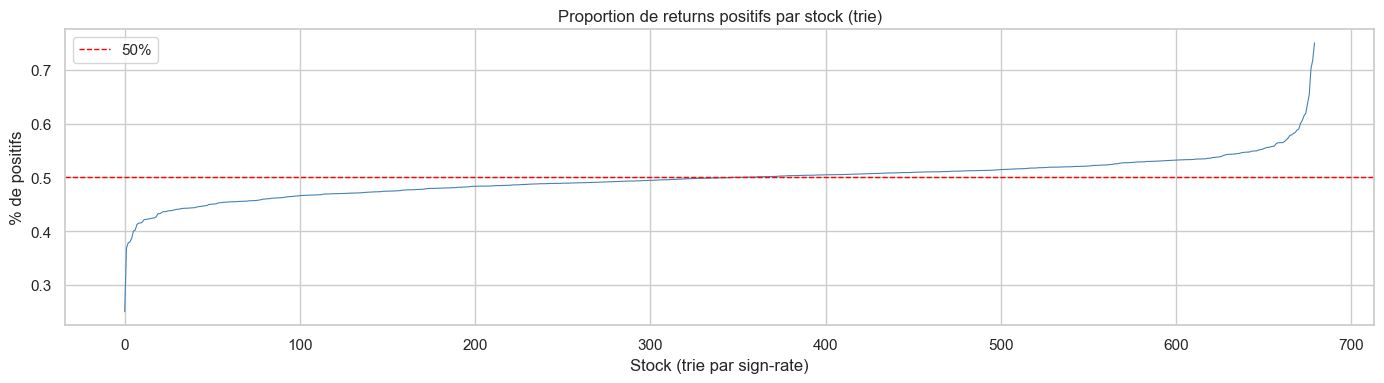

In [15]:
pos_rate = df.groupby('eqt_code')[TARGET].apply(lambda x: (x > 0).mean()).sort_values()

print(f'Sign-rate moyen : {pos_rate.mean():.2%}')
print(f'Min / Max par stock : {pos_rate.min():.2%} / {pos_rate.max():.2%}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pos_rate.values, linewidth=0.8, color='steelblue')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50%')
ax.set_title('Proportion de returns positifs par stock (trie)')
ax.set_xlabel('Stock (trie par sign-rate)')
ax.set_ylabel('% de positifs')
ax.legend()
plt.tight_layout()
plt.show()

Observations par stock :
count     680.0
mean     1096.0
std       510.0
min         4.0
25%       642.0
50%      1484.0
75%      1509.0
max      1511.0
dtype: float64


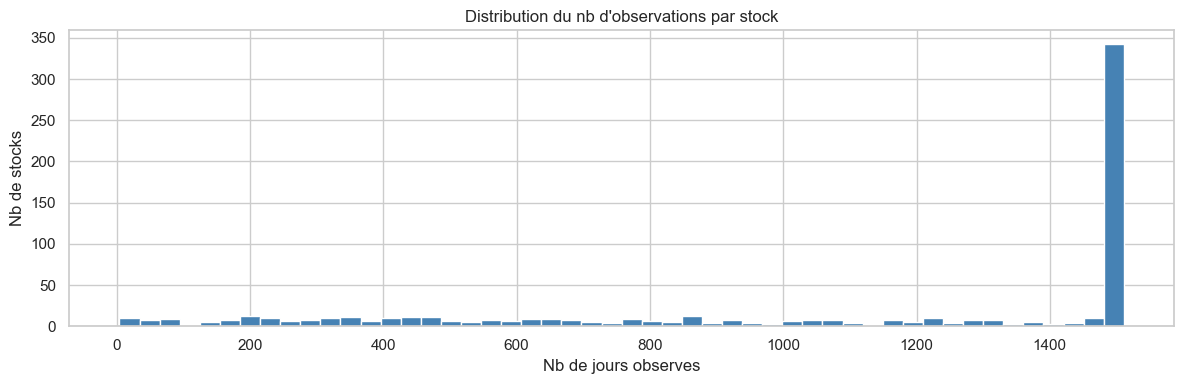

In [16]:
obs_per_stock = X.groupby('eqt_code').size()
print('Observations par stock :')
print(obs_per_stock.describe().round(0))

fig, ax = plt.subplots()
obs_per_stock.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Distribution du nb d'observations par stock")
ax.set_xlabel('Nb de jours observes')
ax.set_ylabel('Nb de stocks')
plt.tight_layout()
plt.show()

---
## Récap — ce qu'on a appris

| Question | Reponse |
|---|---|
| Taille train / test | 745k / ? lignes |
| Stocks / Jours | ? / ? (a completer apres execution) |
| Colonnes returns | 71 creneaux de 9h30 a 15h20 |
| Target | Float continu (return residuel) |
| Equilibre classes | ~50% positifs / ~50% negatifs |
| % NaN global | A verifier |
| Outliers intraday | Extremes → winsorisation a +/-500 |

**Decisions prises pour la suite :**
- Target d'entrainement : return continu → classification binaire (`sign > 0`) ou regression
- Soumission : score continu (threshold a 0.5 par la plateforme)
- NaN → remplaces par 0 pour la baseline
- Winsorisation a +/-500 avant feature engineering